# SaaS Customer Churn — Retention Strategy

**Goal:** Segment customers by churn risk and business value, then
build a concrete retention strategy with projected revenue impact.

This notebook answers the question no model answers on its own:
given we know who is likely to churn, what do we actually do about it?

**Input:** Trained logistic regression model from notebook 03  
**Output:** Customer segments, budget allocation, projected revenue saved

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# Load and rebuild everything from previous notebooks
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
df['Is_New_Customer'] = (df['tenure'] <= 12).astype(int)
df['Is_Monthly_Contract'] = (df['Contract'] == 'Month-to-month').astype(int)
df['Is_Electronic_Check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)
df['Is_Paperless'] = (df['PaperlessBilling'] == 'Yes').astype(int)
df['Has_TechSupport'] = (df['TechSupport'] == 'Yes').astype(int)
df['Has_OnlineSecurity'] = (df['OnlineSecurity'] == 'Yes').astype(int)
df['Has_OnlineBackup'] = (df['OnlineBackup'] == 'Yes').astype(int)
df['Has_DeviceProtection'] = (df['DeviceProtection'] == 'Yes').astype(int)
df['Protective_Services_Score'] = (df['Has_TechSupport'] + df['Has_OnlineSecurity'] +
                                    df['Has_OnlineBackup'] + df['Has_DeviceProtection'])
df['No_Protective_Services'] = (df['Protective_Services_Score'] == 0).astype(int)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Services'] = (df[service_cols] == 'Yes').sum(axis=1)
df['Charge_Per_Service'] = df['MonthlyCharges'] / (df['Total_Services'] + 1)
df['Is_High_Charge'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)
df['High_Risk_Combo'] = ((df['Is_Monthly_Contract'] == 1) & (df['Is_High_Charge'] == 1)).astype(int)
df['No_Partner'] = (df['Partner'] == 'No').astype(int)
df['No_Dependents'] = (df['Dependents'] == 'No').astype(int)
df['Isolation_Score'] = df['No_Partner'] + df['No_Dependents'] + df['SeniorCitizen']

df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['InternetService'], drop_first=False)
df_model['Is_Female'] = (df['gender'] == 'Female').astype(int)

feature_cols = ['tenure', 'Is_New_Customer', 'Is_Monthly_Contract', 'Is_Electronic_Check',
                'Is_Paperless', 'Has_TechSupport', 'Has_OnlineSecurity', 'Has_OnlineBackup',
                'Has_DeviceProtection', 'Protective_Services_Score', 'No_Protective_Services',
                'Total_Services', 'MonthlyCharges', 'TotalCharges', 'Charge_Per_Service',
                'Is_High_Charge', 'High_Risk_Combo', 'SeniorCitizen', 'No_Partner',
                'No_Dependents', 'Isolation_Score', 'InternetService_DSL',
                'InternetService_Fiber optic', 'InternetService_No', 'Is_Female']

X = df_model[feature_cols]
y = df_model['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Get churn probabilities for ALL customers
X_all_scaled = scaler.transform(X)
df['Churn_Probability'] = lr.predict_proba(X_all_scaled)[:, 1]

print(f"Churn probabilities generated for {len(df):,} customers.")
print(f"Average churn probability: {df['Churn_Probability'].mean():.1%}")

Churn probabilities generated for 7,043 customers.
Average churn probability: 26.6%


## 1. Segment customers by risk and value

A model that predicts churn is only useful if it tells you
who to act on. We segment customers into four quadrants:

- High risk, high value — top priority for retention spend
- High risk, low value — low cost interventions only
- Low risk, high value — protect and upsell
- Low risk, low value — minimal spend, monitor only

In [2]:
# Define risk threshold from notebook 03
RISK_THRESHOLD = 0.35

# Define value using monthly charges as proxy for customer value
value_median = df['MonthlyCharges'].median()

# Segment customers
def assign_segment(row):
    high_risk = row['Churn_Probability'] >= RISK_THRESHOLD
    high_value = row['MonthlyCharges'] >= value_median

    if high_risk and high_value:
        return 'High Risk / High Value'
    elif high_risk and not high_value:
        return 'High Risk / Low Value'
    elif not high_risk and high_value:
        return 'Low Risk / High Value'
    else:
        return 'Low Risk / Low Value'

df['Segment'] = df.apply(assign_segment, axis=1)

print(f"Median monthly charge (value threshold): ${value_median:.2f}")
print(f"\nSegment distribution:")
segment_counts = df['Segment'].value_counts()
for segment, count in segment_counts.items():
    pct = count / len(df) * 100
    print(f"  {segment}: {count:,} customers ({pct:.1f}%)")

Median monthly charge (value threshold): $70.35

Segment distribution:
  Low Risk / Low Value: 2,853 customers (40.5%)
  Low Risk / High Value: 1,879 customers (26.7%)
  High Risk / High Value: 1,645 customers (23.4%)
  High Risk / Low Value: 666 customers (9.5%)


## 2. Segment profile analysis

Before recommending interventions we need to understand each
segment, what do they look like, how much do they pay,
and what is at stake if they leave?

In [3]:
segment_profile = df.groupby('Segment').agg(
    Customers=('Churn_Binary', 'count'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Avg_Tenure_Months=('tenure', 'mean'),
    Avg_Churn_Probability=('Churn_Probability', 'mean'),
    Actual_Churn_Rate=('Churn_Binary', 'mean'),
    Monthly_Revenue=('MonthlyCharges', 'sum')
).round(2)

segment_profile['Avg_Monthly_Charges'] = segment_profile['Avg_Monthly_Charges'].map('${:.2f}'.format)
segment_profile['Monthly_Revenue'] = segment_profile['Monthly_Revenue'].map('${:,.0f}'.format)
segment_profile['Avg_Churn_Probability'] = segment_profile['Avg_Churn_Probability'].map('{:.1%}'.format)
segment_profile['Actual_Churn_Rate'] = segment_profile['Actual_Churn_Rate'].map('{:.1%}'.format)
segment_profile['Avg_Tenure_Months'] = segment_profile['Avg_Tenure_Months'].map('{:.0f} months'.format)

print(segment_profile.to_string())

                        Customers Avg_Monthly_Charges Avg_Tenure_Months Avg_Churn_Probability Actual_Churn_Rate Monthly_Revenue
Segment                                                                                                                        
High Risk / High Value       1645              $88.00         17 months                 61.0%             60.0%        $144,756
High Risk / Low Value         666              $50.51          5 months                 51.0%             51.0%         $33,640
Low Risk / High Value        1879              $92.82         54 months                 14.0%             13.0%        $174,406
Low Risk / Low Value         2853              $36.21         33 months                 10.0%             10.0%        $103,314


## 3. Visualize segment distribution and revenue

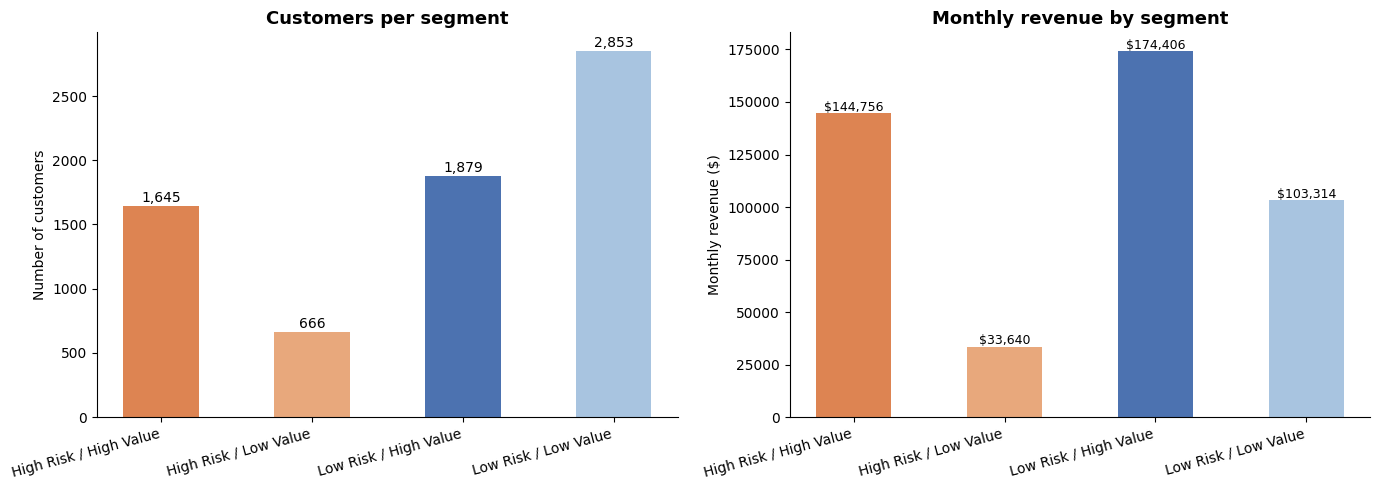

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_order = ['High Risk / High Value', 'High Risk / Low Value',
                 'Low Risk / High Value', 'Low Risk / Low Value']
colors = ['#DD8452', '#E8A87C', '#4C72B0', '#A8C4E0']
counts = [df[df['Segment'] == s].shape[0] for s in segment_order]

bars = axes[0].bar(segment_order, counts, color=colors, width=0.5)
axes[0].set_title('Customers per segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of customers')
axes[0].set_xticks(range(len(segment_order)))
axes[0].set_xticklabels(segment_order, rotation=15, ha='right')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 30,
                f'{val:,}', ha='center', fontsize=10)

revenue = [df[df['Segment'] == s]['MonthlyCharges'].sum() for s in segment_order]
bars2 = axes[1].bar(segment_order, revenue, color=colors, width=0.5)
axes[1].set_title('Monthly revenue by segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Monthly revenue ($)')
axes[1].set_xticks(range(len(segment_order)))
axes[1].set_xticklabels(segment_order, rotation=15, ha='right')
for bar, val in zip(bars2, revenue):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1000,
                f'${val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Revenue at risk

How much monthly revenue are we at risk of losing if we do nothing?

In [5]:
df['Expected_Monthly_Loss'] = df['MonthlyCharges'] * df['Churn_Probability']

revenue_at_risk = df.groupby('Segment').agg(
    Monthly_Revenue=('MonthlyCharges', 'sum'),
    Expected_Loss=('Expected_Monthly_Loss', 'sum')
).round(0)

revenue_at_risk['Loss_Pct'] = (
    revenue_at_risk['Expected_Loss'] / revenue_at_risk['Monthly_Revenue'] * 100
).round(1)

revenue_at_risk['Monthly_Revenue'] = revenue_at_risk['Monthly_Revenue'].map('${:,.0f}'.format)
revenue_at_risk['Expected_Loss'] = revenue_at_risk['Expected_Loss'].map('${:,.0f}'.format)
revenue_at_risk['Loss_Pct'] = revenue_at_risk['Loss_Pct'].map('{:.1f}%'.format)

print("Revenue at risk by segment:")
print(revenue_at_risk.to_string())

Revenue at risk by segment:
                       Monthly_Revenue Expected_Loss Loss_Pct
Segment                                                      
High Risk / High Value        $144,756       $87,443    60.4%
High Risk / Low Value          $33,640       $17,616    52.4%
Low Risk / High Value         $174,406       $24,035    13.8%
Low Risk / Low Value          $103,314       $10,934    10.6%


## 5. Retention strategy and budget allocation

Based on segment profiles and revenue at risk, here is the
recommended intervention per segment and budget allocation.

In [6]:
strategy = {
    'Segment': [
        'High Risk / High Value',
        'High Risk / Low Value',
        'Low Risk / High Value',
        'Low Risk / Low Value'
    ],
    'Intervention': [
        'Proactive outreach + discount offer or contract upgrade incentive',
        'Automated email nudge + one free service add-on trial',
        'Loyalty recognition + upsell to additional services',
        'Monitor only — no active spend'
    ],
    'Budget_Priority': [
        '70% of retention budget',
        '15% of retention budget',
        '15% of retention budget',
        '0% of retention budget'
    ],
    'Expected_Churn_Reduction': [
        '20-30% reduction in churn rate',
        '10-15% reduction in churn rate',
        'Maintain current churn rate',
        'No change expected'
    ]
}

strategy_df = pd.DataFrame(strategy)
print(strategy_df.to_string(index=False))

               Segment                                                      Intervention         Budget_Priority       Expected_Churn_Reduction
High Risk / High Value Proactive outreach + discount offer or contract upgrade incentive 70% of retention budget 20-30% reduction in churn rate
 High Risk / Low Value             Automated email nudge + one free service add-on trial 15% of retention budget 10-15% reduction in churn rate
 Low Risk / High Value               Loyalty recognition + upsell to additional services 15% of retention budget    Maintain current churn rate
  Low Risk / Low Value                                    Monitor only — no active spend  0% of retention budget             No change expected


## 6. Projected revenue saved

If interventions reduce churn in each segment as projected,
how much monthly revenue do we save?

In [7]:
# Current expected monthly loss per segment
raw = df.groupby('Segment').agg(
    Customers=('Churn_Binary', 'count'),
    Monthly_Revenue=('MonthlyCharges', 'sum'),
    Expected_Loss=('Expected_Monthly_Loss', 'sum'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean')
)

# Projected churn reduction per segment
reduction = {
    'High Risk / High Value': 0.25,
    'High Risk / Low Value': 0.125,
    'Low Risk / High Value': 0.0,
    'Low Risk / Low Value': 0.0
}

raw['Churn_Reduction'] = raw.index.map(reduction)
raw['Revenue_Saved'] = (raw['Expected_Loss'] * raw['Churn_Reduction']).round(0)
raw['Total_Expected_Loss'] = raw['Expected_Loss'].round(0)

total_loss = raw['Total_Expected_Loss'].sum()
total_saved = raw['Revenue_Saved'].sum()

print("Projected monthly revenue impact:")
print(f"{'Segment':<30} {'At Risk':>12} {'Saved':>12} {'Reduction':>12}")
print("-" * 68)
for seg in raw.index:
    print(f"{seg:<30} ${raw.loc[seg,'Total_Expected_Loss']:>10,.0f} "
          f"${raw.loc[seg,'Revenue_Saved']:>10,.0f} "
          f"{raw.loc[seg,'Churn_Reduction']:>11.0%}")

print("-" * 68)
print(f"{'TOTAL':<30} ${total_loss:>10,.0f} ${total_saved:>10,.0f}")
print(f"\nProjected monthly revenue saved: ${total_saved:,.0f}")
print(f"Projected annual revenue saved: ${total_saved*12:,.0f}")

Projected monthly revenue impact:
Segment                             At Risk        Saved    Reduction
--------------------------------------------------------------------
High Risk / High Value         $    87,443 $    21,861         25%
High Risk / Low Value          $    17,616 $     2,202         12%
Low Risk / High Value          $    24,035 $         0          0%
Low Risk / Low Value           $    10,934 $         0          0%
--------------------------------------------------------------------
TOTAL                          $   140,028 $    24,063

Projected monthly revenue saved: $24,063
Projected annual revenue saved: $288,756


## 7. Visualize revenue at risk vs revenue saved

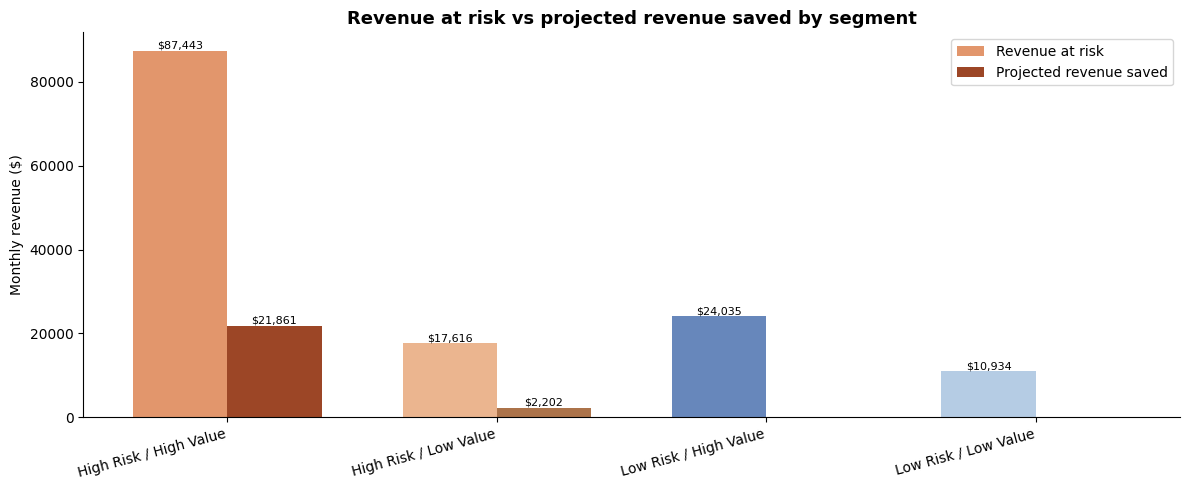

In [8]:
segment_order = ['High Risk / High Value', 'High Risk / Low Value',
                 'Low Risk / High Value', 'Low Risk / Low Value']
colors = ['#DD8452', '#E8A87C', '#4C72B0', '#A8C4E0']

at_risk = [raw.loc[s, 'Total_Expected_Loss'] for s in segment_order]
saved = [raw.loc[s, 'Revenue_Saved'] for s in segment_order]

x = np.arange(len(segment_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, at_risk, width, label='Revenue at risk',
               color=['#DD8452', '#E8A87C', '#4C72B0', '#A8C4E0'], alpha=0.85)
bars2 = ax.bar(x + width/2, saved, width, label='Projected revenue saved',
               color=['#8B2500', '#9E5A2A', '#1A3A6B', '#2E5090'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(segment_order, rotation=15, ha='right')
ax.set_title('Revenue at risk vs projected revenue saved by segment',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly revenue ($)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'${bar.get_height():,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final retention recommendations

Summary of the complete retention strategy with projected impact.

In [9]:
print("=" * 65)
print("RETENTION STRATEGY SUMMARY")
print("=" * 65)

print(f"""
BUSINESS CONTEXT
Total monthly revenue:        $456,116
Total revenue at risk:        $140,028 (30.7% of revenue)
Total customers flagged:       2,311 (32.8% of base)

SEGMENT STRATEGY
1. High Risk / High Value (1,645 customers — 23.4% of base)
   Revenue at risk:   $87,443/month
   Action:            Proactive outreach + contract upgrade incentive
   Budget allocation: 70% of retention spend
   Projected impact:  25% churn reduction → $21,861/month saved

2. High Risk / Low Value (666 customers — 9.5% of base)
   Revenue at risk:   $17,616/month
   Action:            Automated email + free service add-on trial
   Budget allocation: 15% of retention spend
   Projected impact:  12.5% churn reduction → $2,202/month saved

3. Low Risk / High Value (1,879 customers — 26.7% of base)
   Revenue at risk:   $24,035/month
   Action:            Loyalty recognition + upsell campaign
   Budget allocation: 15% of retention spend
   Projected impact:  Protect and grow — maintain current churn rate

4. Low Risk / Low Value (2,853 customers — 40.5% of base)
   Revenue at risk:   $10,934/month
   Action:            Monitor only
   Budget allocation: 0%

PROJECTED OUTCOME
Monthly revenue saved:   $24,063
Annual revenue saved:    $288,756
""")
print("=" * 65)

RETENTION STRATEGY SUMMARY

BUSINESS CONTEXT
Total monthly revenue:        $456,116
Total revenue at risk:        $140,028 (30.7% of revenue)
Total customers flagged:       2,311 (32.8% of base)

SEGMENT STRATEGY
1. High Risk / High Value (1,645 customers — 23.4% of base)
   Revenue at risk:   $87,443/month
   Action:            Proactive outreach + contract upgrade incentive
   Budget allocation: 70% of retention spend
   Projected impact:  25% churn reduction → $21,861/month saved

2. High Risk / Low Value (666 customers — 9.5% of base)
   Revenue at risk:   $17,616/month
   Action:            Automated email + free service add-on trial
   Budget allocation: 15% of retention spend
   Projected impact:  12.5% churn reduction → $2,202/month saved

3. Low Risk / High Value (1,879 customers — 26.7% of base)
   Revenue at risk:   $24,035/month
   Action:            Loyalty recognition + upsell campaign
   Budget allocation: 15% of retention spend
   Projected impact:  Protect and grow — m

## 9. Key findings and project summary

### What this project built

A full churn prediction and retention prioritization system, from raw data to a dollar-quantified business recommendation.

### Results

| Metric | Value |
|--------|-------|
| Model | Logistic Regression |
| AUC-ROC | 0.839 on held-out test set |
| Recall at threshold 0.35 | 70.1% — catches 7 in 10 churners |
| Total revenue at risk | $140,028/month |
| Projected revenue saved | $24,063/month |
| Projected annual impact | $288,756 |

### Key insight from SHAP

EDA suggested contract type was the dominant churn driver.
SHAP revealed MonthlyCharges and internet service type actually
drive model predictions more. Correlation and causation differ, and the model caught what the raw analysis missed.

### Retention recommendation

Concentrate 70% of retention budget on the High Risk / High Value
segment (1,645 customers, $87,443/month at risk). Low cost automated
interventions for High Risk / Low Value. Protect and upsell
Low Risk / High Value. No spend on Low Risk / Low Value.

### What I would do next with more time

- Add customer support interaction data as features
- Build a survival analysis model to predict time-to-churn
- Deploy the model as a weekly scoring pipeline
- A/B test retention interventions to validate projected impact